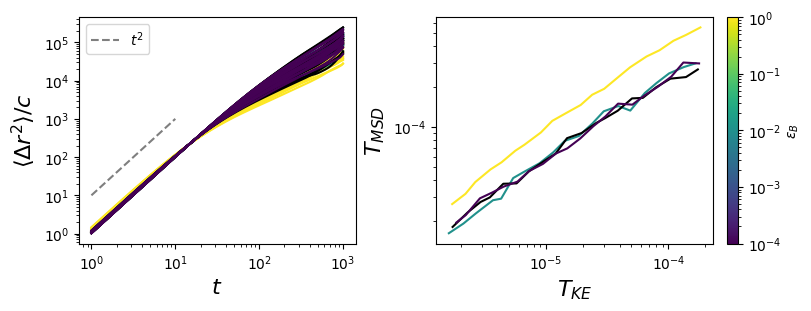

In [8]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
from file_management import load_arrs
from config import config2d_soft as cfg
import jaxdem as jd
import jax.numpy as jnp
import os

fig, ax = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

softness_map = {
    'floppy': -1,
    'soft': 0,
    'med': 1,
    'hard': 2,
}
softnesses = np.array([1e-4, 1e-2, 1e0])
cmap = plt.cm.viridis
norm = LogNorm(min(softnesses), max(softnesses))

root = '/home/mmccraw/dev/data/26-01-01/grant/dp-temperature'
for i, softness in enumerate(os.listdir(root)):
    if softness.split('2d-')[-1] == 'floppy':
        c = 'k'
    else:
        c = cmap(norm(softnesses[softness_map[softness.split('2d-')[-1]]]))

    temps, T_obs, T_true = [], [], []
    for temperature in os.listdir(os.path.join(root, softness)):
        path = os.path.join(root, softness, temperature, 'phi-0.600071')
        temperature = float(temperature)
        
        try:
            data = load_arrs(os.path.join(path, 'traj', 'data.h5'))
        except:
            continue
        ke = data['ke']
        pe = data['pe']
        pos_dp = data['pos_dp']
        vel_dp = data['vel_dp']
        msd = data['msd']

        dim = 2  # spatial dimension
        sigma = 1.0  # particle diameter
        time_unit = sigma * np.sqrt(cfg.mass / cfg.e_int)
        t = data['t_dimless'] * cfg.dt * cfg.save_stride

        ballistic_mask = t < 3e1
        x = np.log10(t[ballistic_mask])
        y = np.log10(msd[ballistic_mask])
        a, b = np.polyfit(x, y, deg=1)
        b = np.mean(y - 2 * x)
        D_short = 10 ** b
        n = a

        # ax[0].plot(t[ballistic_mask], t[ballistic_mask] ** n, c=c)

        state = jd.utils.h5.load(os.path.join(path, 'final', 'state.h5'))
        T_obs.append(D_short * cfg.mass / dim)
        T_true.append(2 * np.mean(ke) / (cfg.dim * state.N))
        temps.append(temperature)
        ax[0].plot(t, msd / D_short, c=c)
    temps = np.array(temps)
    T_obs = np.array(T_obs)[np.argsort(temps)]
    T_true = np.array(T_true)[np.argsort(temps)]
    temps = np.sort(temps)

    ax[1].plot(T_true, T_obs, c=c)
    # ax[2].plot(temps, T_true / temps, c=c)
x = np.logspace(0, 1)
ax[0].plot(x, 10 * x ** 2, color='k', alpha=0.5, ls='--', label=r'$t^2$')
ax[0].legend()
ax[0].set_xlabel(r'$t$', fontsize=16)
ax[0].set_ylabel(r'$\langle \Delta r^2 \rangle / c$', fontsize=16)
ax[1].set_xlabel(r'$T_{KE}$', fontsize=16)
ax[1].set_ylabel(r'$T_{MSD}$', fontsize=16)
# ax[2].set_xlabel(r'$T_0$', fontsize=16)
# ax[2].set_ylabel(r'$T_{KE}$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array(np.unique(softnesses))
cbar = plt.colorbar(sm, ax=ax[-1], label=r'$\varepsilon_B$')

for a in ax:
    a.set_yscale('log')
    a.set_xscale('log')
plt.savefig('determining-dp-temperature-from-msd.png', dpi=600)

In [122]:
root = '/home/mmccraw/dev/data/26-01-01/grant/dp-temperature-animations/'
for i, softness in enumerate(os.listdir(root)):
    print(softness)
    break

state_traj = jd.utils.h5.load(os.path.join(root, softness, 'phi-0.600071', 'traj', 'state_traj.h5'))
system_traj = jd.utils.h5.load(os.path.join(root, softness, 'phi-0.600071', 'traj', 'system_traj.h5'))

2d-hard


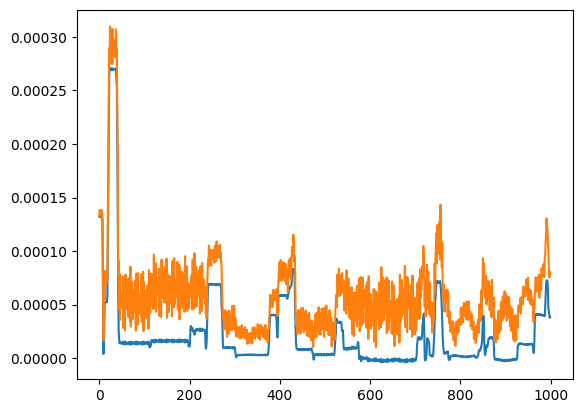

In [123]:
dpid = state_traj.deformable_ID[0].copy()

# jnp.sum((vi[:, None, :] * vi[None, ...])[..., 0], axis=-1)

vi = state_traj.vel[:, dpid == 0]
vel_corrs = jnp.sum(vi[:, :, None, :] * vi[:, None, ...], axis=-1)
v_com_2 = vel_corrs[:, *jnp.diag_indices_from(vel_corrs[0])]
v_off = vel_corrs[:, ~jnp.eye(vi.shape[1], dtype=bool)]

plt.plot(jnp.mean(v_off, axis=-1))
plt.plot(jnp.mean(v_com_2, axis=-1))